<a href="https://colab.research.google.com/github/Sun06naina/DPL-Codes/blob/main/OR_trained.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initial Weights and Bias:
Weights: [-0.25091976  0.90142861]
Bias: 0.000

Training Single Perceptron (OR Gate)...
Iteration 0: Loss = 0.4235
Iteration 1000: Loss = 0.2693
Iteration 2000: Loss = 0.2290

Training Complete!
Final Weights: W1=1.818, W2=2.053
Final Bias: -0.531

Predictions:
Input [0 0] → 0.370 → Class 0
Input [0 1] → 0.821 → Class 1
Input [1 0] → 0.784 → Class 1
Input [1 1] → 0.966 → Class 1


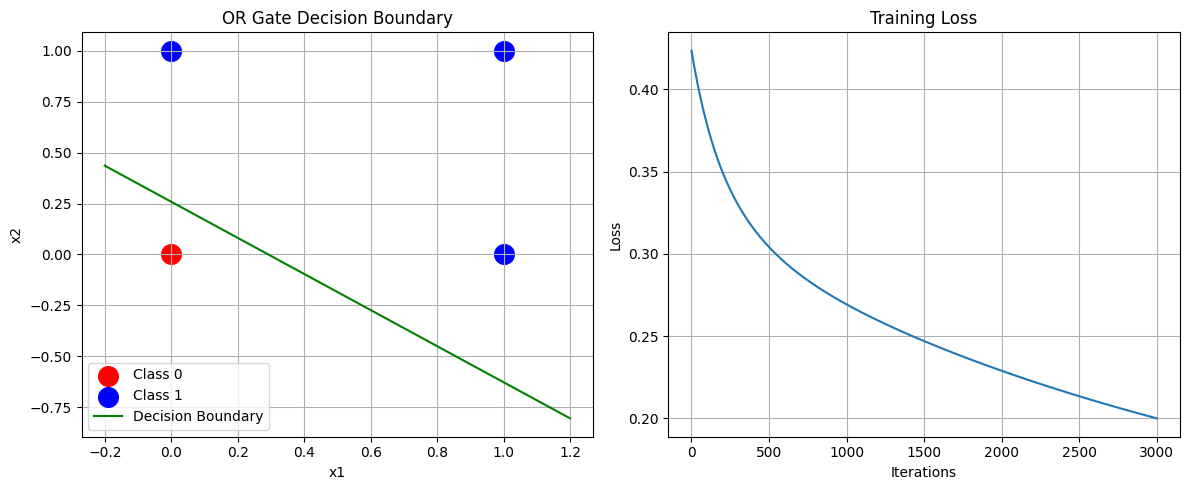


Decision Boundary Equation:
1.818*x1 + 2.053*x2 + -0.531 = 0


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
input_size = 2
learning_rate = 0.01
iterations = 3000
print_interval = 1000

# Dataset (FIXED)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [1]])

# Initialize weights
np.random.seed(42)
weights = np.random.uniform(-1, 1, (input_size, 1))
bias = np.array([[0.0]])

print("Initial Weights and Bias:")
print(f"Weights: {weights.flatten()}")
print(f"Bias: {bias[0,0]:.3f}")

# Sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -250, 250)))

# Derivative
def sigmoid_derivative(x):
    return x * (1 - x)

# Prediction
def predict(X, weights, bias):
    return sigmoid(np.dot(X, weights) + bias)

# Training
print("\nTraining Single Perceptron (OR Gate)...")
loss_history = []

for iteration in range(iterations):
    linear_output = np.dot(X, weights) + bias
    output = sigmoid(linear_output)

    error = y - output
    d_output = error * sigmoid_derivative(output)

    # Update weights
    weights += learning_rate * np.dot(X.T, d_output)
    bias += learning_rate * np.sum(d_output, axis=0, keepdims=True)

    loss = np.mean(np.abs(error))
    loss_history.append(loss)

    if iteration % print_interval == 0:
        print(f"Iteration {iteration}: Loss = {loss:.4f}")

print("\nTraining Complete!")
print(f"Final Weights: W1={weights[0,0]:.3f}, W2={weights[1,0]:.3f}")
print(f"Final Bias: {bias[0,0]:.3f}")

# Predictions
final_predictions = predict(X, weights, bias)

print("\nPredictions:")
for i in range(len(X)):
    pred_class = 1 if final_predictions[i,0] > 0.5 else 0
    print(f"Input {X[i]} → {final_predictions[i,0]:.3f} → Class {pred_class}")

# Plot
plt.figure(figsize=(12,5))

# Scatter
plt.subplot(1,2,1)
plt.scatter(X[y.flatten()==0, 0], X[y.flatten()==0, 1], c='red', s=200, label='Class 0')
plt.scatter(X[y.flatten()==1, 0], X[y.flatten()==1, 1], c='blue', s=200, label='Class 1')

# Decision boundary
w1, w2 = weights[0,0], weights[1,0]
b = bias[0,0]
x1 = np.linspace(-0.2, 1.2, 100)

if abs(w2) > 1e-6:
    x2 = (-w1 * x1 - b) / w2
    plt.plot(x1, x2, 'g', label='Decision Boundary')
else:
    plt.axvline(x=-b/w1, color='g', label='Decision Boundary')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('OR Gate Decision Boundary')
plt.legend()
plt.grid()

# Loss graph
plt.subplot(1,2,2)
plt.plot(loss_history)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid()

plt.tight_layout()
plt.show()

# Verification
print("\nDecision Boundary Equation:")
print(f"{weights[0,0]:.3f}*x1 + {weights[1,0]:.3f}*x2 + {bias[0,0]:.3f} = 0")